In [1]:
from demo_model import SGG_Model
import cv2
import os

import matplotlib.pyplot as plt

config_path = "../checkpoints/IndoorVG/test3/config.yml"
weights_path = "../checkpoints/IndoorVG/test3/best_model_epoch_1.pth"

source = "./example.jpg"
model = SGG_Model(config_path, weights_path, rel_conf=0.1, box_conf=0.01, show_fps=False)

2026-01-27 18:01:21.025 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:264 - ----------------------------------------------------------------------------------------------------
2026-01-27 18:01:21.025 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:265 - get dataset statistics...
2026-01-27 18:01:21.026 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:308 - Loading data statistics from: ../checkpoints/IndoorVG/test3/custom_dataset_train_statistics.cache
2026-01-27 18:01:21.026 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:309 - ----------------------------------------------------------------------------------------------------


2026-01-27 18:01:21.241 | INFO     | sgg_benchmark.utils.logger:setup_logger:31 - Using loguru logger with level: INFO
Overriding model.yaml nc=80 with nc=84
YOLO Backbone FROZEN - no gradients will be computed
Transferred 22/475 items from pretrained weights


## Atention visualization

No pairs found with object scores > 0.35. Falling back to all detected pairs.


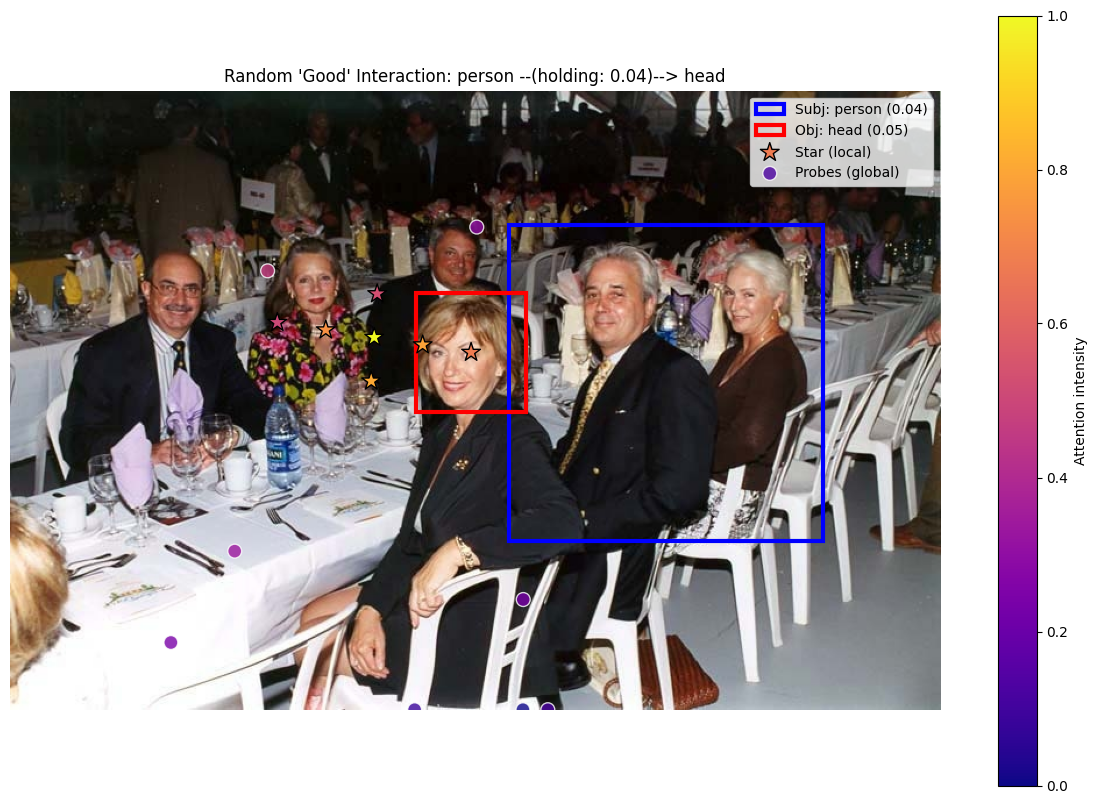

In [12]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

# 1. Run inference with return_attention=True
img = cv2.imread(source)
res = model.predict(img, return_attention=True)

# 2. Visualize Relationship Interaction Attention
# Note: In SGDET mode, the result dictionary uses "pred_rel_scores" and "pred_labels"
if "rel_points" in res and "rel_attention" in res:
    # Get labels and classes for display
    obj_classes = model.stats['obj_classes']
    rel_classes = model.stats['rel_classes']
    
    # Relationship and Object scores
    rel_scores = res["pred_rel_scores"]
    obj_scores = res["pred_scores"]
    pair_idxs = res["rel_pair_idxs"]
    
    max_rel_scores, pred_rels = rel_scores[:, 1:].max(dim=1)
    pred_rels = pred_rels + 1
    
    # Filter for "good pairs": both Sbj and Obj must have score > 0.35
    sbj_mask = obj_scores[pair_idxs[:, 0]] > 0.5
    obj_mask = obj_scores[pair_idxs[:, 1]] > 0.5
    good_pair_mask = sbj_mask & obj_mask
    
    # Combine with a minimum relation score threshold to avoid noisy/background rels
    final_mask = good_pair_mask & (max_rel_scores > 0.05)
    
    valid_indices = torch.nonzero(final_mask).flatten()
    if len(valid_indices) == 0:
        print("No pairs found with object scores > 0.35. Falling back to all detected pairs.")
        valid_indices = torch.arange(len(max_rel_scores))
    
    # Sample a random interaction from the filtered list
    top_idx = valid_indices[torch.randint(0, len(valid_indices), (1,))].item()
    
    pair = pair_idxs[top_idx]
    sbj_box = res["boxes"][pair[0]].cpu().numpy()
    obj_box = res["boxes"][pair[1]].cpu().numpy()
    
    # Object labels (1-indexed mapping to list)
    sbj_label = obj_classes[res["pred_labels"][pair[0]].item() - 1]
    obj_label = obj_classes[res["pred_labels"][pair[1]].item() - 1]
    rel_label = rel_classes[pred_rels[top_idx].item()]
    
    score = max_rel_scores[top_idx].item()
    sbj_conf = obj_scores[pair[0]].item()
    obj_conf = obj_scores[pair[1]].item()
    
    # Get points and attention
    pts = res["rel_points"][top_idx].cpu().numpy()
    h, w = img.shape[:2]
    pts[:, 0] = np.clip(pts[:, 0], 0, w - 1)
    pts[:, 1] = np.clip(pts[:, 1], 0, h - 1)
    
    attn = res["rel_attention"][-1, top_idx, :, 0, :].mean(0).view(3, 15).sum(0).cpu().numpy()
    if attn.max() > 0:
        attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

    # Plotting
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax = plt.gca()
    
    # Draw Boxes
    ax.add_patch(plt.Rectangle((sbj_box[0], sbj_box[1]), sbj_box[2]-sbj_box[0], sbj_box[3]-sbj_box[1], 
                               fill=False, edgecolor='blue', linewidth=3, 
                               label=f'Subj: {sbj_label} ({sbj_conf:.2f})'))
    ax.add_patch(plt.Rectangle((obj_box[0], obj_box[1]), obj_box[2]-obj_box[0], obj_box[3]-obj_box[1], 
                               fill=False, edgecolor='red', linewidth=3, 
                               label=f'Obj: {obj_label} ({obj_conf:.2f})'))
    
    # Draw Sampling Points
    plt.scatter(pts[:7, 0], pts[:7, 1], c=attn[:7], cmap='plasma', s=200, marker='*', edgecolors='black', label='Star (local)', vmin=0, vmax=1)
    plt.scatter(pts[7:, 0], pts[7:, 1], c=attn[7:], cmap='plasma', s=100, marker='o', edgecolors='white', alpha=0.8, label='Probes (global)', vmin=0, vmax=1)
    
    plt.title(f"Random 'Good' Interaction: {sbj_label} --({rel_label}: {score:.2f})--> {obj_label}")
    plt.legend()
    
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=0, vmax=1))
    plt.colorbar(sm, ax=ax, label='Attention intensity')
    
    plt.axis('off')
    plt.show()
else:
    print("Relationship data not found. Ensure model is running in a configuration with a relationship head.")


In [3]:
if '.jpg' in source:
    example_img = source

    img = cv2.imread(example_img)

    clean_img, graph = model.predict(img, visu_type='image')

elif os.path.isdir(source):
    os.makedirs(source + '/results', exist_ok=True)

    for file in os.listdir(source):
        example_img = source + '/' + file

        if '.jpg' not in example_img:
            continue

        img = cv2.imread(example_img)

        clean_img, graph = model.predict(img, visu_type='image')

        # to rgb
        clean_img = cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB)
        # save to dir
        cv2.imwrite(source + '/results/res_' + file, clean_img)

tensor([59, 37, 78, 59, 77, 37, 15, 59, 12, 15, 16, 12, 15, 35, 12, 59, 59, 12, 29, 29, 59, 59, 71], device='cuda:0', dtype=torch.int32)
Objects detected:  23
Relationships detected:  240


/home/maelicneau/Documents/SGG-Benchmark/demo/demo_model.py:515: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  subj_indices = torch.searchsorted(unique_values, filtered_rels[:, 0])


ImportError: requires pygraphviz http://pygraphviz.github.io/

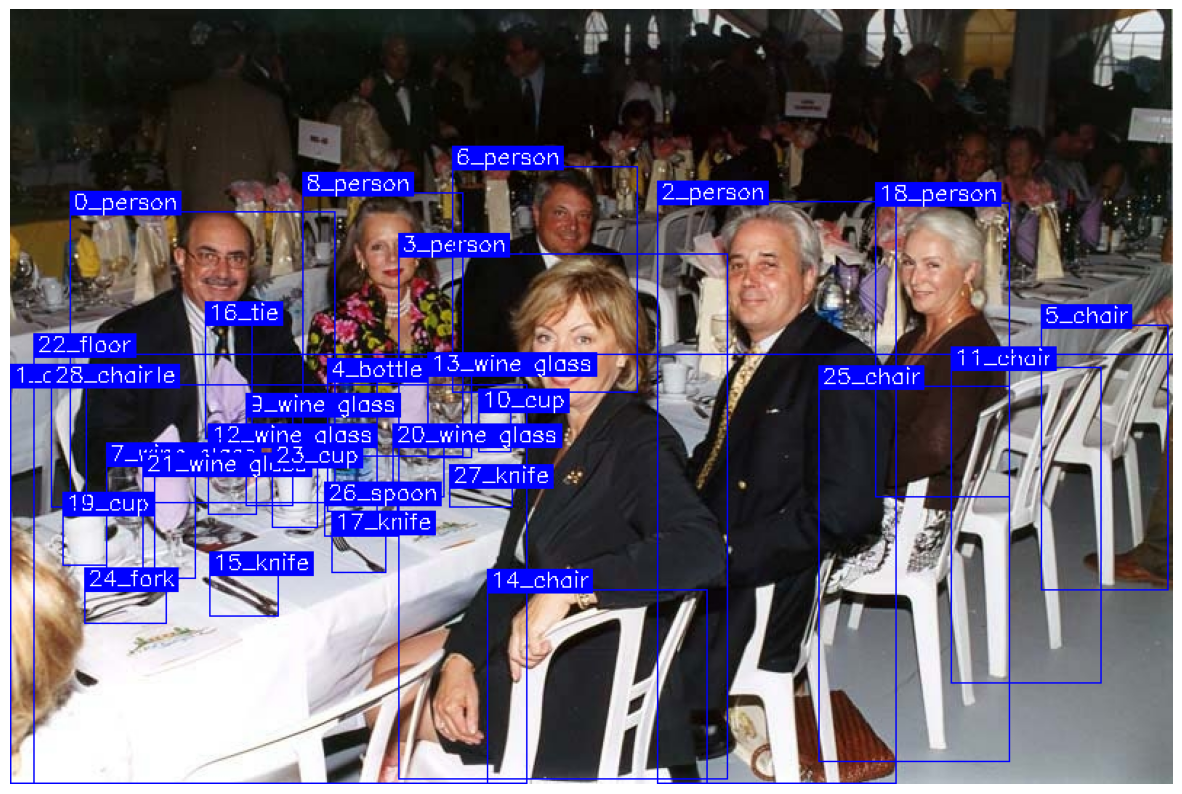

In [ ]:
plt.figure(figsize=(15, 15))  # You can adjust the size as needed
plt.imshow(clean_img)
plt.axis('off')
plt.show()

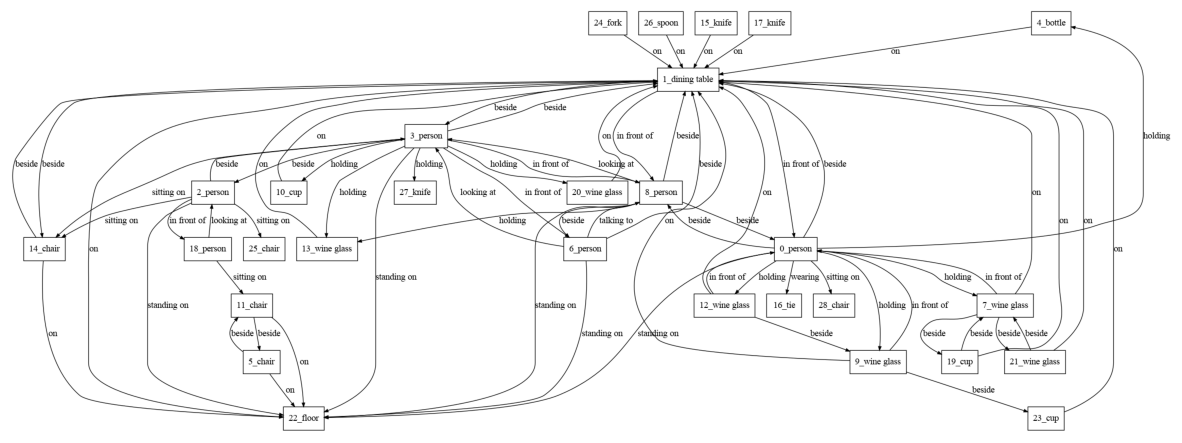

In [ ]:
plt.figure(figsize=(15, 8))  # You can adjust the size as needed
plt.imshow(graph)
plt.axis('off')
plt.show()